# Estudio de caída de consumo

Segundo notebook de la fase de segmentación. Lee la salida del agrupamiento
(`clientes_clusters_consumo.parquet`) y determina qué clientes han bajado su
consumo de forma significativa.

## Diseño

**Ventana según la periodicidad de lectura.** Los clientes con lectura mensual
se evalúan sobre los **últimos 3 meses**; los de lectura trimestral (rurales)
sobre los **últimos 6 meses**, porque con lecturas cada 3 meses una ventana de
3 contiene una sola lectura real repartida por la reconstrucción, y cualquier
variación medida ahí es un artefacto del reparto, no una señal.

**Dos comparaciones, no una.**
- *Periodo anterior*: la ventana reciente contra la ventana inmediatamente
  previa. Detecta la caída que empezó hace poco.
- *Año contra año*: la ventana reciente contra el mismo periodo calendario del
  año anterior. Descuenta la estacionalidad.

Un cliente que cae en ambas es una caída real y sostenida. Uno que cae solo
contra el periodo anterior puede ser estacionalidad. Uno que cae solo contra
el año pasado viene bajando desde antes, sin agravarse ahora. Los tres casos
significan cosas distintas para el negocio, así que se reportan por separado.

**El umbral es relativo a su segmento, no global.** Una caída del 15% en
`URBANO_BASE_ESTABLE` (cuyos clientes varían casi nada) es una anomalía seria;
la misma caída en `RURAL_INTERMITENTE_CRITICO` es ruido normal. Por eso cada
cliente se compara contra la distribución de variación de **su propio
segmento**, usando una escala robusta (IQR), y no contra un número fijo para
todos.

**Criterio dual: porcentaje o kWh, según lo que discrimine en cada segmento.**
En los segmentos de consumo bajo la variación porcentual es intrínsecamente
ruidosa —para un cliente de 7 kWh, ±48 puntos porcentuales es *una* desviación
normal—, así que su umbral estadístico se hunde más allá de -100%, donde ya
no puede distinguir nada. En esos segmentos el criterio cambia a **kWh
perdidos al mes**: deja de importar el porcentaje y pasa a importar cuánta
energía se dejó de vender, que es lo que el negocio puede accionar. Cada
segmento elige su criterio a partir de sus propios datos, y queda registrado.

**Severidad relativa, no absoluta.** La severidad se mide en escalas robustas
*más allá* del umbral del propio segmento, no con un corte porcentual fijo.
Con umbrales relativos, un corte fijo hacía que todo lo marcado en los
segmentos exigentes fuera "crítico" por construcción.

**Descubrimiento vs. confirmación.** Un cliente cayendo dentro de un segmento
estable es un hallazgo: caer ahí no es normal. Uno cayendo dentro de
`CAIDA_SEVERA` no es noticia — el agrupamiento ya lo había marcado. Se
reportan separados para que la lista no se infle con circularidad.

## Salida

- `estudio_caida_consumo.parquet` — un registro por NIU con las dos variaciones,
  los kWh perdidos, el criterio aplicado, el veredicto y la severidad.
- `resumen_caida_por_segmento.csv` — tabla para negocio.
- `clientes_caida_prioritarios.csv` — caída confirmada, ordenada por kWh perdidos.


In [1]:
# ============================================================
# 1. LIBRERÍAS Y RUTAS
# ============================================================

from pathlib import Path
import gc

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE_DIR = Path(r"C:\Users\Home\Documents\Datos Ebsa")

PREPROC_DIR = BASE_DIR / "Serie_tiempo_consumo" / "preprocesamiento_modelo"
AGRUP_DIR = BASE_DIR / "Serie_tiempo_consumo" / "agrupamiento_clientes"

CAIDA_DIR = BASE_DIR / "Serie_tiempo_consumo" / "estudio_caida"
CAIDA_DIR.mkdir(parents=True, exist_ok=True)

RUTA_SERIE = PREPROC_DIR / "serie_mensual_modelado_preprocesada.parquet"
RUTA_CLUSTERS = AGRUP_DIR / "clientes_clusters_consumo.parquet"

RUTA_CAIDA = CAIDA_DIR / "estudio_caida_consumo.parquet"
RUTA_RESUMEN_SEGMENTO = CAIDA_DIR / "resumen_caida_por_segmento.csv"
RUTA_PRIORITARIOS = CAIDA_DIR / "clientes_caida_prioritarios.csv"
RUTA_DIAGNOSTICO_BORDE = CAIDA_DIR / "diagnostico_borde_ventana.csv"
RUTA_CRITERIOS = CAIDA_DIR / "criterios_caida_por_segmento.joblib"
RUTA_CRITERIOS_CSV = CAIDA_DIR / "criterios_caida_por_segmento.csv"

# --- Ventanas de evaluación ---
MESES_VENTANA_MENSUAL = 3      # clientes con lectura mensual
MESES_VENTANA_TRIMESTRAL = 6   # clientes con lectura trimestral (rurales)

# El diagnóstico de la celda 3 detectó que el último periodo trae, en RURAL,
# un consumo medio del 47.9% del nivel normal con la cobertura de clientes
# intacta: es el borde incompleto de la reconstrucción trimestral, no una
# caída. Incluirlo sesga la ventana reciente -8.7% en rural y -17.4% en
# mensual. Con retroceso de 1, la ventana termina en el último mes completo.
MESES_RETROCESO_VENTANA = 1

# --- Umbrales ---
# Estadístico: cuántas escalas robustas por debajo de la mediana de SU segmento
K_DESVIACIONES = 2.0

# El umbral de cada segmento se ACOTA a esta banda. Las dos cotas importan:
#  - El piso (-10%) evita reportar caídas irrelevantes en segmentos ultra
#    estables, por muy anómalas que sean estadísticamente.
#  - El techo (-60%) es lo que faltaba en la primera versión: en segmentos muy
#    volátiles el umbral estadístico caía a -108%, -247% e incluso -2660%, y
#    como la variación porcentual no puede bajar de -100%, esos segmentos eran
#    INDETECTABLES por construcción. Perder el 100% del consumo debe marcar
#    alarma en cualquier segmento.
UMBRAL_MINIMO_CAIDA_PCT = -10.0   # piso: nunca menos exigente que esto
UMBRAL_MAXIMO_CAIDA_PCT = -60.0   # techo: nunca más exigente que esto

# Cuando el porcentaje no discrimina (segmentos de consumo bajo), el criterio
# pasa a kWh perdidos. Por debajo de esta pérdida no vale una gestión.
UMBRAL_MINIMO_PERDIDA_KWH = 10.0

# Mínimo de meses con dato en cada ventana para que la comparación sea válida
def minimo_validos(n_meses):
    return max(2, int(np.ceil(n_meses * 0.6)))

SEED = 42

print("Serie      :", RUTA_SERIE)
print("Segmentos  :", RUTA_CLUSTERS)
print("Salidas    :", CAIDA_DIR)
print()
print(f"Ventana mensual    : {MESES_VENTANA_MENSUAL} meses "
      f"(mínimo {minimo_validos(MESES_VENTANA_MENSUAL)} con dato)")
print(f"Ventana trimestral : {MESES_VENTANA_TRIMESTRAL} meses "
      f"(mínimo {minimo_validos(MESES_VENTANA_TRIMESTRAL)} con dato)")


Serie      : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\preprocesamiento_modelo\serie_mensual_modelado_preprocesada.parquet
Segmentos  : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\clientes_clusters_consumo.parquet
Salidas    : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida

Ventana mensual    : 3 meses (mínimo 2 con dato)
Ventana trimestral : 6 meses (mínimo 4 con dato)


## Cargar segmentos y serie

In [2]:
# ============================================================
# 2. CARGAR LA SEGMENTACIÓN Y LA SERIE MENSUAL
# ============================================================

for ruta in (RUTA_SERIE, RUTA_CLUSTERS):
    if not ruta.exists():
        raise FileNotFoundError(f"No existe:\n{ruta}")

clusters = pd.read_parquet(RUTA_CLUSTERS, engine="pyarrow")
clusters["NIU"] = clusters["NIU"].astype("string").str.strip()

columnas_necesarias = {
    "NIU", "cluster_id", "segmento_base", "zona",
    "es_rural_final", "segmento_prioridad",
}
faltantes = columnas_necesarias - set(clusters.columns)
if faltantes:
    raise ValueError(
        f"Al parquet de segmentos le faltan columnas: {sorted(faltantes)}. "
        "Vuelve a correr el notebook de agrupamiento."
    )

serie = pd.read_parquet(
    RUTA_SERIE, columns=["NIU", "periodo", "consumo_kwh_mensual"], engine="pyarrow",
)
serie["NIU"] = serie["NIU"].astype("string").str.strip()
serie["periodo"] = pd.to_datetime(serie["periodo"], errors="coerce")
serie["consumo_kwh_mensual"] = pd.to_numeric(
    serie["consumo_kwh_mensual"], errors="coerce"
).astype("float32")

periodo_max = serie["periodo"].max().to_period("M").to_timestamp()

print("SEGMENTACIÓN")
print("-" * 60)
print(f"Clientes  : {len(clusters):,}")
print(f"Segmentos : {clusters['cluster_id'].nunique()}")

print("\nSERIE")
print("-" * 60)
print(f"Filas          : {len(serie):,}")
print(f"NIU únicos     : {serie['NIU'].nunique():,}")
print(f"Último periodo : {periodo_max:%Y-%m}")

if len(clusters) != serie["NIU"].nunique():
    print(
        f"\n⚠ La segmentación tiene {len(clusters):,} clientes y la serie "
        f"{serie['NIU'].nunique():,}. Se trabajará sobre la intersección."
    )


SEGMENTACIÓN
------------------------------------------------------------
Clientes  : 592,159
Segmentos : 15

SERIE
------------------------------------------------------------
Filas          : 26,888,751
NIU únicos     : 592,159
Último periodo : 2026-01


## Diagnóstico previo: ¿el último mes de la ventana está truncado?

Antes de medir cualquier caída hay que descartar un artefacto. Si el último mes
de la serie tiene menos clientes con lectura o un consumo medio mucho más bajo
que los anteriores, entonces **toda** la población parecerá estar cayendo, y lo
que estaríamos midiendo es el corte de los datos, no el comportamiento de los
clientes. Esto es especialmente probable en los rurales, donde la
reconstrucción trimestral reparte una lectura entre varios meses y el último
tramo puede quedar incompleto.

Si el diagnóstico muestra un desplome en el borde, la ventana reciente debe
retroceder un mes.


,zona,periodo,clientes_con_dato,pct_vs_referencia_clientes,consumo_medio_kwh,pct_vs_referencia_consumo
0,RURAL,2025-11-01,215185,100.4,52.93,102.599998
1,RURAL,2025-12-01,215187,100.4,54.65,105.900002
2,RURAL,2026-01-01,216835,101.2,24.72,47.900002
3,URBANO,2025-11-01,358369,101.4,161.81,97.400002
4,URBANO,2025-12-01,359558,101.7,159.83,96.199997
5,URBANO,2026-01-01,360525,102.0,161.09,97.000000


LECTURA DEL DIAGNÓSTICO
----------------------------------------------------------------------
⚠ Meses con cobertura o consumo anormalmente bajos:


,zona,periodo,clientes_con_dato,pct_vs_referencia_clientes,consumo_medio_kwh,pct_vs_referencia_consumo
2,RURAL,2026-01-01,216835,101.2,24.72,47.900002


Si el mes más reciente aparece aquí, considera retroceder la ventana
un mes antes de interpretar los resultados: la caída medida incluiría
el efecto del corte de datos.


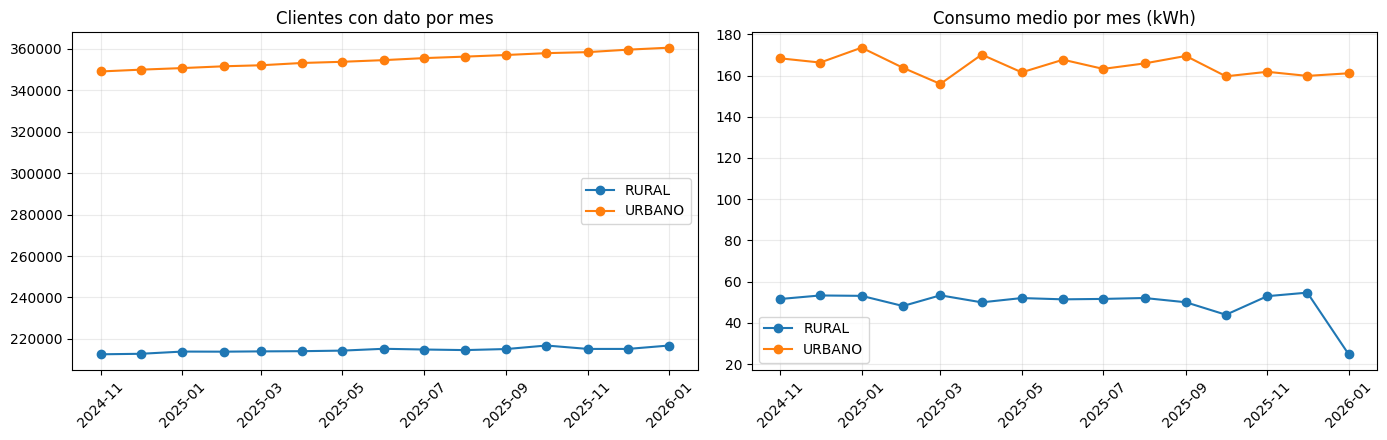

2292

In [3]:
# ============================================================
# 3. DIAGNÓSTICO DEL BORDE DE LA VENTANA
# ============================================================

meses_diag = pd.date_range(end=periodo_max, periods=15, freq="MS")

serie_diag = serie[serie["periodo"].isin(meses_diag)].merge(
    clusters[["NIU", "es_rural_final"]], on="NIU", how="inner",
)

diagnostico = (
    serie_diag
    .groupby(["es_rural_final", "periodo"])
    .agg(
        clientes_con_dato=("consumo_kwh_mensual", lambda s: int(s.notna().sum())),
        consumo_medio_kwh=("consumo_kwh_mensual", "mean"),
    )
    .reset_index()
)

diagnostico["zona"] = np.where(diagnostico["es_rural_final"], "RURAL", "URBANO")

# Comparar cada mes contra la mediana de los 12 meses previos de su zona
alertas = []
for zona, grupo in diagnostico.groupby("zona"):
    grupo = grupo.sort_values("periodo")
    referencia_clientes = grupo["clientes_con_dato"].iloc[:-3].median()
    referencia_consumo = grupo["consumo_medio_kwh"].iloc[:-3].median()

    for _, fila in grupo.tail(3).iterrows():
        pct_clientes = fila["clientes_con_dato"] / referencia_clientes * 100
        pct_consumo = fila["consumo_medio_kwh"] / referencia_consumo * 100
        alertas.append({
            "zona": zona,
            "periodo": fila["periodo"],
            "clientes_con_dato": int(fila["clientes_con_dato"]),
            "pct_vs_referencia_clientes": round(pct_clientes, 1),
            "consumo_medio_kwh": round(fila["consumo_medio_kwh"], 2),
            "pct_vs_referencia_consumo": round(pct_consumo, 1),
        })

alertas = pd.DataFrame(alertas)
display(alertas)

alertas.to_csv(RUTA_DIAGNOSTICO_BORDE, index=False, encoding="utf-8-sig")

print("LECTURA DEL DIAGNÓSTICO")
print("-" * 70)
sospechosos = alertas[
    (alertas["pct_vs_referencia_clientes"] < 90)
    | (alertas["pct_vs_referencia_consumo"] < 85)
]
if len(sospechosos):
    print("⚠ Meses con cobertura o consumo anormalmente bajos:")
    display(sospechosos)
    print(
        "Si el mes más reciente aparece aquí, considera retroceder la ventana\n"
        "un mes antes de interpretar los resultados: la caída medida incluiría\n"
        "el efecto del corte de datos."
    )
else:
    print("✓ Ningún mes reciente muestra cobertura ni consumo anormalmente bajos.")
    print("  El borde de la ventana no parece truncado.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (columna, titulo) in zip(
    axes,
    [("clientes_con_dato", "Clientes con dato por mes"),
     ("consumo_medio_kwh", "Consumo medio por mes (kWh)")],
):
    for zona, grupo in diagnostico.groupby("zona"):
        grupo = grupo.sort_values("periodo")
        ax.plot(grupo["periodo"], grupo[columna], marker="o", label=zona)
    ax.set_title(titulo)
    ax.grid(alpha=0.25)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

del serie_diag
gc.collect()


## Construir las ventanas de comparación

In [4]:
# ============================================================
# 4. MATRIZ NIU x MES (24 meses, suficiente para las tres ventanas)
# ============================================================

meses_matriz = pd.date_range(end=periodo_max, periods=24, freq="MS")

todos_los_niu = pd.Index(
    clusters["NIU"].astype("string").unique(), name="NIU"
).sort_values()

wide = (
    serie[serie["periodo"].isin(meses_matriz)]
    [["NIU", "periodo", "consumo_kwh_mensual"]]
    .pivot(index="NIU", columns="periodo", values="consumo_kwh_mensual")
    .reindex(index=todos_los_niu, columns=meses_matriz)
    .astype("float32")
)

nius = wide.index.astype("string").to_numpy()
matriz = wide.to_numpy(dtype="float32", copy=False)
indice_mes = {mes: i for i, mes in enumerate(meses_matriz)}

print(f"Matriz: {matriz.shape[0]:,} clientes x {matriz.shape[1]} meses")
print(f"Rango : {meses_matriz[0]:%Y-%m} → {meses_matriz[-1]:%Y-%m}")

del wide
gc.collect()


Matriz: 592,159 clientes x 24 meses
Rango : 2024-02 → 2026-01


0

In [5]:
# ============================================================
# 5. DEFINIR LAS TRES VENTANAS POR PERIODICIDAD
# ============================================================

# El retroceso desplaza LAS TRES ventanas por igual, para que sigan siendo
# comparables entre sí: si solo se moviera la reciente, la comparación
# quedaría descuadrada.
periodo_fin = periodo_max - pd.DateOffset(months=MESES_RETROCESO_VENTANA)


def ventana(n_meses, offset_meses):
    """n_meses terminando `offset_meses` antes del fin de ventana efectivo."""
    fin = periodo_fin - pd.DateOffset(months=offset_meses)
    return pd.date_range(end=fin, periods=n_meses, freq="MS")


VENTANAS = {}

for etiqueta, n in [
    ("MENSUAL", MESES_VENTANA_MENSUAL),
    ("TRIMESTRAL", MESES_VENTANA_TRIMESTRAL),
]:
    VENTANAS[etiqueta] = {
        "n_meses": n,
        "reciente": ventana(n, 0),
        "anterior": ventana(n, n),
        "anio_pasado": ventana(n, 12),
    }

print("VENTANAS DE COMPARACIÓN")
print("=" * 70)
print(f"Último periodo de la serie : {periodo_max:%Y-%m}")
print(f"Retroceso aplicado         : {MESES_RETROCESO_VENTANA} mes(es)")
print(f"Fin de ventana efectivo    : {periodo_fin:%Y-%m}")
for etiqueta, v in VENTANAS.items():
    print(f"\n{etiqueta} ({v['n_meses']} meses)")
    for nombre in ["reciente", "anterior", "anio_pasado"]:
        rango = v[nombre]
        print(f"  {nombre:<12}: {rango[0]:%Y-%m} → {rango[-1]:%Y-%m}")

# Verificar que todas las ventanas caben en la matriz
for etiqueta, v in VENTANAS.items():
    for nombre in ["reciente", "anterior", "anio_pasado"]:
        faltan = [m for m in v[nombre] if m not in indice_mes]
        if faltan:
            raise ValueError(
                f"La ventana {nombre} de {etiqueta} necesita meses fuera de la "
                f"matriz: {[f'{m:%Y-%m}' for m in faltan]}"
            )
print("\n✓ Todas las ventanas caben en la matriz de 24 meses.")


VENTANAS DE COMPARACIÓN
Último periodo de la serie : 2026-01
Retroceso aplicado         : 1 mes(es)
Fin de ventana efectivo    : 2025-12

MENSUAL (3 meses)
  reciente    : 2025-10 → 2025-12
  anterior    : 2025-07 → 2025-09
  anio_pasado : 2024-10 → 2024-12

TRIMESTRAL (6 meses)
  reciente    : 2025-07 → 2025-12
  anterior    : 2025-01 → 2025-06
  anio_pasado : 2024-07 → 2024-12

✓ Todas las ventanas caben en la matriz de 24 meses.


In [6]:
# ============================================================
# 6. CONSUMO PROMEDIO POR VENTANA
# ============================================================
# Se usa el promedio de los meses CON dato, no la suma: si a un cliente le
# falta un mes, la suma lo castigaría como si hubiera consumido cero.
# ============================================================

def promedio_ventana(meses, min_validos):
    cols = [indice_mes[m] for m in meses]
    sub = matriz[:, cols]

    validos = (~np.isnan(sub)).sum(axis=1)

    with np.errstate(invalid="ignore"):
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            promedio = np.nanmean(sub, axis=1).astype("float64")

    promedio[validos < min_validos] = np.nan
    return promedio, validos


# La periodicidad decide qué ventana aplica a cada cliente
es_rural = (
    clusters.set_index("NIU")["es_rural_final"]
    .reindex(nius)
    .fillna(False)
    .to_numpy(dtype=bool)
)

n_clientes = len(nius)
promedios = {
    nombre: np.full(n_clientes, np.nan, dtype="float64")
    for nombre in ["reciente", "anterior", "anio_pasado"]
}
meses_validos = {
    nombre: np.zeros(n_clientes, dtype="int16")
    for nombre in ["reciente", "anterior", "anio_pasado"]
}
n_meses_cliente = np.where(es_rural, MESES_VENTANA_TRIMESTRAL, MESES_VENTANA_MENSUAL)

for etiqueta, mascara in [("MENSUAL", ~es_rural), ("TRIMESTRAL", es_rural)]:
    v = VENTANAS[etiqueta]
    minimo = minimo_validos(v["n_meses"])

    for nombre in ["reciente", "anterior", "anio_pasado"]:
        prom, val = promedio_ventana(v[nombre], minimo)
        promedios[nombre][mascara] = prom[mascara]
        meses_validos[nombre][mascara] = val[mascara]

print("COBERTURA DE LAS VENTANAS")
print("-" * 70)
for nombre in ["reciente", "anterior", "anio_pasado"]:
    n_ok = int(np.isfinite(promedios[nombre]).sum())
    print(
        f"  {nombre:<12}: {n_ok:,} clientes con promedio válido "
        f"({n_ok / n_clientes * 100:.1f}%)"
    )


COBERTURA DE LAS VENTANAS
----------------------------------------------------------------------
  reciente    : 573,451 clientes con promedio válido (96.8%)
  anterior    : 569,963 clientes con promedio válido (96.3%)
  anio_pasado : 560,329 clientes con promedio válido (94.6%)


## Variaciones y umbral relativo al segmento

In [7]:
# ============================================================
# 7. VARIACIÓN PORCENTUAL EN LAS DOS COMPARACIONES
# ============================================================

def variacion_pct(reciente, referencia):
    """% de cambio del promedio reciente frente a una referencia.
    Devuelve NaN si la referencia es 0 o falta algún dato: no se puede
    hablar de caída porcentual desde cero."""
    salida = np.full(len(reciente), np.nan, dtype="float64")
    valido = (
        np.isfinite(reciente) & np.isfinite(referencia) & (referencia > 0)
    )
    salida[valido] = (
        (reciente[valido] - referencia[valido]) / referencia[valido] * 100
    )
    return salida


var_vs_anterior = variacion_pct(promedios["reciente"], promedios["anterior"])
var_vs_anio = variacion_pct(promedios["reciente"], promedios["anio_pasado"])

caida = pd.DataFrame({
    "NIU": nius,
    "meses_ventana": n_meses_cliente.astype("int16"),
    "consumo_reciente_kwh": promedios["reciente"],
    "consumo_anterior_kwh": promedios["anterior"],
    "consumo_anio_pasado_kwh": promedios["anio_pasado"],
    "meses_validos_reciente": meses_validos["reciente"],
    "meses_validos_anterior": meses_validos["anterior"],
    "meses_validos_anio_pasado": meses_validos["anio_pasado"],
    "variacion_vs_anterior_pct": var_vs_anterior,
    "variacion_vs_anio_pct": var_vs_anio,
})

caida = caida.merge(
    clusters[[
        "NIU", "cluster_id", "segmento_base", "zona",
        "es_rural_final", "segmento_prioridad",
    ]],
    on="NIU", how="left",
)

print("VARIACIONES CALCULADAS")
print("-" * 70)
print(f"  vs. periodo anterior : {int(caida['variacion_vs_anterior_pct'].notna().sum()):,}")
print(f"  vs. año pasado       : {int(caida['variacion_vs_anio_pct'].notna().sum()):,}")

display(
    caida[["variacion_vs_anterior_pct", "variacion_vs_anio_pct"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
)


VARIACIONES CALCULADAS
----------------------------------------------------------------------
  vs. periodo anterior : 534,778
  vs. año pasado       : 525,974


,count,mean,std,min,5%,25%,50%,75%,95%,max
variacion_vs_anterior_pct,534778.0,93.312504,5714.280203,-100.0,-68.423272,-14.792897,-2.173913,10.620334,115.392378,2.571636e+06
variacion_vs_anio_pct,525974.0,224.752531,13121.717127,-100.0,-84.615385,-22.033897,-1.999992,19.739385,227.792397,7.088938e+06


In [8]:
# ============================================================
# 8. UMBRAL POR SEGMENTO — CRITERIO DUAL (% o kWh)
# ============================================================
# Por qué dual: en segmentos de consumo bajo la variación porcentual es
# intrínsecamente ruidosa (para un cliente de 7 kWh, ±48 puntos porcentuales
# es UNA desviación normal). Ahí el umbral estadístico se hunde por debajo
# de -100%, más allá de lo que la variación puede alcanzar, y acotarlo al
# techo termina marcando casi todo el segmento.
#
# En esos segmentos el criterio cambia a kWh perdidos: deja de importar el
# porcentaje y pasa a importar cuánta energía se dejó de vender, que es lo
# que el negocio puede accionar. Un cliente de 7 kWh que cae a 3 sale de la
# lista; uno de 500 que cae a 200 entra.
# ============================================================

SEGMENTOS_SIN_EVALUAR = {"SIN_CONSUMO", "NUEVO_O_SIN_DATOS"}
SEGMENTOS_ESTABLES = {"BASE_ESTABLE", "BASE_EN_DESCENSO"}


def escala_robusta(serie_datos):
    """Mediana y escala robusta (IQR/1.349) de una serie."""
    mediana = serie_datos.median()
    iqr = serie_datos.quantile(0.75) - serie_datos.quantile(0.25)
    escala = iqr / 1.349
    if not np.isfinite(escala) or escala <= 0:
        escala = serie_datos.std()
    if not np.isfinite(escala) or escala <= 0:
        escala = 0.5
    return mediana, max(escala, 0.5)


# --- kWh perdidos (positivo = perdió consumo) ---
caida["perdida_vs_anterior_kwh"] = (
    caida["consumo_anterior_kwh"] - caida["consumo_reciente_kwh"]
)
caida["perdida_vs_anio_kwh"] = (
    caida["consumo_anio_pasado_kwh"] - caida["consumo_reciente_kwh"]
)


def construir_umbrales(df, col_pct, col_kwh):
    """Una fila por segmento: qué criterio usa y con qué umbral."""

    evaluables = df[~df["segmento_base"].isin(SEGMENTOS_SIN_EVALUAR)]
    filas = []

    for segmento, grupo in evaluables.groupby("cluster_id"):

        pct = grupo[col_pct].dropna()
        kwh = grupo[col_kwh].dropna()

        if len(pct) < 10:
            continue

        med_pct, esc_pct = escala_robusta(pct)
        umbral_pct_bruto = med_pct - K_DESVIACIONES * esc_pct

        med_kwh, esc_kwh = escala_robusta(kwh) if len(kwh) >= 10 else (0.0, 0.5)
        # Cola SUPERIOR: perder mucho es lo anómalo
        umbral_kwh = max(
            med_kwh + K_DESVIACIONES * esc_kwh, UMBRAL_MINIMO_PERDIDA_KWH
        )

        # El criterio lo decide el propio dato: si el umbral porcentual se
        # hunde más allá del techo, el porcentaje no discrimina en ese segmento.
        usa_kwh = umbral_pct_bruto < UMBRAL_MAXIMO_CAIDA_PCT

        filas.append({
            "cluster_id": segmento,
            "n": len(pct),
            "criterio": "KWH" if usa_kwh else "PORCENTAJE",
            "mediana_pct": med_pct,
            "escala_pct": esc_pct,
            "umbral_pct_bruto": umbral_pct_bruto,
            "umbral_pct": min(umbral_pct_bruto, UMBRAL_MINIMO_CAIDA_PCT),
            "mediana_kwh": med_kwh,
            "escala_kwh": esc_kwh,
            "umbral_kwh": umbral_kwh,
        })

    return pd.DataFrame(filas).set_index("cluster_id")


umbrales_anterior = construir_umbrales(
    caida, "variacion_vs_anterior_pct", "perdida_vs_anterior_kwh"
)
umbrales_anio = construir_umbrales(
    caida, "variacion_vs_anio_pct", "perdida_vs_anio_kwh"
)

print("CRITERIO Y UMBRAL POR SEGMENTO (comparación vs. periodo anterior)")
print("=" * 78)
print(f"K = {K_DESVIACIONES} | techo porcentual = {UMBRAL_MAXIMO_CAIDA_PCT:.0f}% "
      f"| pérdida mínima accionable = {UMBRAL_MINIMO_PERDIDA_KWH:.0f} kWh/mes\n")

tabla_umbrales = umbrales_anterior[[
    "n", "criterio", "mediana_pct", "escala_pct",
    "umbral_pct_bruto", "umbral_pct", "umbral_kwh",
]].round(2).sort_values(["criterio", "umbral_pct"])

display(tabla_umbrales)

n_kwh = int((umbrales_anterior["criterio"] == "KWH").sum())
print(f"\nSegmentos evaluados por kWh perdidos : {n_kwh}")
print(f"Segmentos evaluados por porcentaje    : "
      f"{len(umbrales_anterior) - n_kwh}")
print(
    "\nEn los de criterio KWH la columna umbral_pct_bruto muestra por qué: "
    "el\numbral porcentual caía más allá del techo, donde ya no discrimina nada."
)


CRITERIO Y UMBRAL POR SEGMENTO (comparación vs. periodo anterior)
K = 2.0 | techo porcentual = -60% | pérdida mínima accionable = 10 kWh/mes



,n,criterio,mediana_pct,escala_pct,umbral_pct_bruto,umbral_pct,umbral_kwh
cluster_id,,,,,,,
RURAL_EN_REACTIVACION,4215,KWH,770.27,1374.08,-1977.88,-1977.88,22.74
URBANO_EN_REACTIVACION,6119,KWH,155.71,389.29,-622.87,-622.87,53.14
URBANO_CAIDA_SEVERA,8764,KWH,-16.67,91.19,-199.04,-199.04,10.71
RURAL_CAIDA_SEVERA,7239,KWH,-84.99,18.64,-122.28,-122.28,34.19
RURAL_BASE_ESTABLE_BAJO,76684,KWH,-4.61,47.66,-99.93,-99.93,10.00
URBANO_BASE_ESTABLE_BAJO,43613,KWH,0.00,35.48,-70.95,-70.95,10.00
RURAL_BASE_ESTABLE_GRANDE,2471,PORCENTAJE,-1.46,21.30,-44.07,-44.07,236.70
RURAL_BASE_ESTABLE_MEDIO,82193,PORCENTAJE,-1.47,18.84,-39.14,-39.14,21.17
RURAL_BASE_ESTABLE_ALTO,22013,PORCENTAJE,-1.09,17.94,-36.97,-36.97,51.50



Segmentos evaluados por kWh perdidos : 6
Segmentos evaluados por porcentaje    : 6

En los de criterio KWH la columna umbral_pct_bruto muestra por qué: el
umbral porcentual caía más allá del techo, donde ya no discrimina nada.


In [9]:
# ============================================================
# 9. CLASIFICAR LA CAÍDA
# ============================================================

def evaluar_comparacion(df, col_pct, col_kwh, tabla):
    """Devuelve (marcado, exceso_en_escalas) según el criterio del segmento.

    `exceso` mide cuántas escalas robustas MÁS ALLÁ del umbral está el
    cliente. Es la base de la severidad: al ser relativa al segmento, un
    mismo nivel de severidad significa lo mismo en todos ellos, cosa que
    un corte porcentual fijo no lograba."""

    criterio = df["cluster_id"].map(tabla["criterio"])
    umbral_pct = df["cluster_id"].map(tabla["umbral_pct"])
    umbral_kwh = df["cluster_id"].map(tabla["umbral_kwh"])
    escala_pct = df["cluster_id"].map(tabla["escala_pct"])
    escala_kwh = df["cluster_id"].map(tabla["escala_kwh"])

    es_pct = criterio == "PORCENTAJE"
    es_kwh = criterio == "KWH"

    marcado = (
        (es_pct & (df[col_pct] <= umbral_pct))
        | (es_kwh & (df[col_kwh] >= umbral_kwh))
    ).fillna(False)

    exceso = pd.Series(np.nan, index=df.index, dtype="float64")
    exceso[es_pct] = ((umbral_pct - df[col_pct]) / escala_pct)[es_pct]
    exceso[es_kwh] = ((df[col_kwh] - umbral_kwh) / escala_kwh)[es_kwh]

    return marcado, exceso


caida["cae_vs_anterior"], exceso_anterior = evaluar_comparacion(
    caida, "variacion_vs_anterior_pct", "perdida_vs_anterior_kwh",
    umbrales_anterior,
)
caida["cae_vs_anio"], exceso_anio = evaluar_comparacion(
    caida, "variacion_vs_anio_pct", "perdida_vs_anio_kwh", umbrales_anio,
)

caida["criterio_evaluacion"] = caida["cluster_id"].map(
    umbrales_anterior["criterio"]
).fillna("NO_EVALUADO")

# Los segmentos no evaluables nunca se marcan
no_evaluable = caida["segmento_base"].isin(SEGMENTOS_SIN_EVALUAR)
caida.loc[no_evaluable, ["cae_vs_anterior", "cae_vs_anio"]] = False

# --- Veredicto combinado ---
sin_datos = (
    caida["variacion_vs_anterior_pct"].isna()
    & caida["variacion_vs_anio_pct"].isna()
)

condiciones = [
    no_evaluable,
    sin_datos,
    caida["cae_vs_anterior"] & caida["cae_vs_anio"],
    caida["cae_vs_anterior"],
    caida["cae_vs_anio"],
]
resultados = [
    "NO_APLICA",
    "SIN_BASE_COMPARABLE",
    "CAIDA_CONFIRMADA",
    "CAIDA_RECIENTE",
    "CAIDA_SOSTENIDA",
]
caida["veredicto"] = np.select(condiciones, resultados, default="SIN_CAIDA")

tiene_caida = caida["veredicto"].isin(
    ["CAIDA_CONFIRMADA", "CAIDA_RECIENTE", "CAIDA_SOSTENIDA"]
)

# --- Severidad RELATIVA al umbral del propio segmento ---
# Antes era un corte porcentual fijo (-50% = CRITICA), incoherente con un
# umbral relativo: en un segmento con umbral en -60%, todo lo marcado era
# crítico por construcción. Ahora se mide en escalas más allá del umbral.
caida["exceso_escalas"] = pd.concat(
    [exceso_anterior, exceso_anio], axis=1
).max(axis=1)

caida["severidad"] = np.select(
    [
        tiene_caida & (caida["exceso_escalas"] >= 2.0),
        tiene_caida & (caida["exceso_escalas"] >= 1.0),
        tiene_caida,
    ],
    ["CRITICA", "FUERTE", "MODERADA"],
    default="NINGUNA",
)

# --- Magnitudes de negocio ---
caida["caida_pct"] = caida[
    ["variacion_vs_anterior_pct", "variacion_vs_anio_pct"]
].min(axis=1)
caida["perdida_kwh_mes"] = caida[
    ["perdida_vs_anterior_kwh", "perdida_vs_anio_kwh"]
].max(axis=1).clip(lower=0)

# --- Descubrimiento vs. confirmación ---
# Un cliente cayendo dentro de un segmento ESTABLE es un hallazgo: caer ahí
# no es normal. Uno cayendo dentro de CAIDA_SEVERA no es noticia — el
# agrupamiento ya lo había marcado. Mezclarlos infla la lista con
# circularidad.
caida["tipo_hallazgo"] = np.where(
    ~tiene_caida, "NINGUNO",
    np.where(
        caida["segmento_base"].isin(SEGMENTOS_ESTABLES),
        "DESCUBRIMIENTO", "CONFIRMACION",
    ),
)

print("VEREDICTO")
print("=" * 70)
resumen_veredicto = (
    caida["veredicto"].value_counts().rename("n_clientes").to_frame()
)
resumen_veredicto["pct"] = (
    resumen_veredicto["n_clientes"] / len(caida) * 100
).round(2)
display(resumen_veredicto)

print("\nSEVERIDAD (relativa al umbral de cada segmento)")
print("-" * 70)
display(
    caida.loc[tiene_caida, "severidad"]
    .value_counts()
    .rename("n_clientes")
    .to_frame()
)

print("\nDESCUBRIMIENTO vs. CONFIRMACIÓN")
print("-" * 70)
tabla_hallazgo = pd.crosstab(
    caida.loc[tiene_caida, "tipo_hallazgo"],
    caida.loc[tiene_caida, "veredicto"],
)
display(tabla_hallazgo)
print(
    "DESCUBRIMIENTO = cae dentro de un segmento estable (caer ahí no es normal).\n"
    "CONFIRMACION   = cae dentro de un segmento que el agrupamiento ya había\n"
    "                 marcado como no estable. Confirma, no descubre."
)

print("\nSIGNIFICADO DE CADA VEREDICTO")
print("-" * 70)
print("  CAIDA_CONFIRMADA    : cae contra el periodo anterior Y contra el año")
print("                        pasado. Señal más fuerte, no es estacionalidad.")
print("  CAIDA_RECIENTE      : solo contra el periodo anterior. Empezó hace poco,")
print("                        o puede ser efecto estacional. Vigilar.")
print("  CAIDA_SOSTENIDA     : solo contra el año pasado. Viene bajando desde")
print("                        antes, sin agravarse en los últimos meses.")
print("  SIN_CAIDA           : dentro de lo normal para su segmento.")
print("  SIN_BASE_COMPARABLE : sin historia suficiente en las ventanas.")
print("  NO_APLICA           : ya estaba en cero, o sin historia (no hay de qué caer).")


VEREDICTO


,n_clientes,pct
veredicto,,
SIN_CAIDA,480101,81.08
NO_APLICA,46012,7.77
CAIDA_RECIENTE,22020,3.72
CAIDA_SOSTENIDA,21734,3.67
CAIDA_CONFIRMADA,15896,2.68
SIN_BASE_COMPARABLE,6396,1.08



SEVERIDAD (relativa al umbral de cada segmento)
----------------------------------------------------------------------


,n_clientes
severidad,
MODERADA,27247
CRITICA,21089
FUERTE,11314



DESCUBRIMIENTO vs. CONFIRMACIÓN
----------------------------------------------------------------------


veredicto,CAIDA_CONFIRMADA,CAIDA_RECIENTE,CAIDA_SOSTENIDA
tipo_hallazgo,,,
CONFIRMACION,848,1913,1386
DESCUBRIMIENTO,15048,20107,20348


DESCUBRIMIENTO = cae dentro de un segmento estable (caer ahí no es normal).
CONFIRMACION   = cae dentro de un segmento que el agrupamiento ya había
                 marcado como no estable. Confirma, no descubre.

SIGNIFICADO DE CADA VEREDICTO
----------------------------------------------------------------------
  CAIDA_CONFIRMADA    : cae contra el periodo anterior Y contra el año
                        pasado. Señal más fuerte, no es estacionalidad.
  CAIDA_RECIENTE      : solo contra el periodo anterior. Empezó hace poco,
                        o puede ser efecto estacional. Vigilar.
  CAIDA_SOSTENIDA     : solo contra el año pasado. Viene bajando desde
                        antes, sin agravarse en los últimos meses.
  SIN_CAIDA           : dentro de lo normal para su segmento.
  SIN_BASE_COMPARABLE : sin historia suficiente en las ventanas.
  NO_APLICA           : ya estaba en cero, o sin historia (no hay de qué caer).


## Consolidar, resumir y priorizar

In [10]:
# ============================================================
# 10. GUARDAR EL DETALLE POR CLIENTE
# ============================================================

columnas_salida = [
    "NIU", "cluster_id", "segmento_base", "zona", "es_rural_final",
    "meses_ventana",
    "consumo_reciente_kwh", "consumo_anterior_kwh", "consumo_anio_pasado_kwh",
    "variacion_vs_anterior_pct", "variacion_vs_anio_pct",
    "perdida_vs_anterior_kwh", "perdida_vs_anio_kwh",
    "criterio_evaluacion", "exceso_escalas",
    "cae_vs_anterior", "cae_vs_anio",
    "veredicto", "tipo_hallazgo", "caida_pct", "perdida_kwh_mes", "severidad",
    "segmento_prioridad",
]

caida_salida = caida[columnas_salida].copy()
caida_salida.to_parquet(RUTA_CAIDA, index=False, engine="pyarrow")

print("Guardado:", RUTA_CAIDA)
print(f"Registros: {len(caida_salida):,}")
display(caida_salida.head(10))


Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\estudio_caida_consumo.parquet
Registros: 592,159


,NIU,cluster_id,segmento_base,zona,es_rural_final,meses_ventana,consumo_reciente_kwh,consumo_anterior_kwh,consumo_anio_pasado_kwh,variacion_vs_anterior_pct,...,criterio_evaluacion,exceso_escalas,cae_vs_anterior,cae_vs_anio,veredicto,tipo_hallazgo,caida_pct,perdida_kwh_mes,severidad,segmento_prioridad
0,1000006589,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,79.333336,31.666666,72.000000,150.526329,...,PORCENTAJE,-2.416913,False,False,SIN_CAIDA,NINGUNO,10.185189,0.000000,NINGUNA,5
1,1000007366,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,79.000000,78.666664,78.333336,0.423732,...,PORCENTAJE,-2.065505,False,False,SIN_CAIDA,NINGUNO,0.423732,0.000000,NINGUNA,5
2,1000008143,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,53.333332,45.333332,64.666664,17.647059,...,PORCENTAJE,-1.373660,False,False,SIN_CAIDA,NINGUNO,-17.525772,11.333332,NINGUNA,5
3,100000949,RURAL_BASE_ESTABLE_MEDIO,BASE_ESTABLE,RURAL,True,6,39.564072,28.008387,54.320038,41.257946,...,PORCENTAJE,-0.982401,False,False,SIN_CAIDA,NINGUNO,-27.164867,14.755966,NINGUNA,5
4,1000009920,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,70.333336,78.000000,40.666668,-9.829057,...,PORCENTAJE,-1.451607,False,False,SIN_CAIDA,NINGUNO,-9.829057,7.666664,NINGUNA,5
5,1000010766,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,83.000000,105.000000,120.333336,-20.952381,...,PORCENTAJE,-0.684425,False,False,SIN_CAIDA,NINGUNO,-31.024932,37.333336,NINGUNA,5
6,100001726,RURAL_SIN_CONSUMO,SIN_CONSUMO,RURAL,True,6,0.000000,0.000000,0.614035,NaN,...,NO_EVALUADO,NaN,False,False,NO_APLICA,NINGUNO,-100.000000,0.614035,NINGUNA,2
7,100002503,RURAL_BASE_ESTABLE_BAJO,BASE_ESTABLE,RURAL,True,6,13.774963,13.927850,10.821931,-1.097703,...,KWH,-3.103687,False,False,SIN_CAIDA,NINGUNO,-1.097703,0.152886,NINGUNA,5
8,100003390,RURAL_BASE_ESTABLE_MEDIO,BASE_ESTABLE,RURAL,True,6,26.966665,33.133694,24.508413,-18.612559,...,PORCENTAJE,-1.089895,False,False,SIN_CAIDA,NINGUNO,-18.612559,6.167028,NINGUNA,5
9,100004177,RURAL_BASE_ESTABLE_MEDIO,BASE_ESTABLE,RURAL,True,6,43.516846,27.829300,12.795700,56.370609,...,PORCENTAJE,-5.070525,False,False,SIN_CAIDA,NINGUNO,56.370609,0.000000,NINGUNA,5


In [11]:
# ============================================================
# 11. RESUMEN POR SEGMENTO (TABLA PARA NEGOCIO)
# ============================================================

resumen_segmento = (
    caida
    .groupby("cluster_id")
    .agg(
        n_clientes=("NIU", "size"),
        variacion_mediana_vs_anterior=("variacion_vs_anterior_pct", "median"),
        variacion_mediana_vs_anio=("variacion_vs_anio_pct", "median"),
        n_caida_confirmada=("veredicto", lambda s: int((s == "CAIDA_CONFIRMADA").sum())),
        n_caida_reciente=("veredicto", lambda s: int((s == "CAIDA_RECIENTE").sum())),
        n_caida_sostenida=("veredicto", lambda s: int((s == "CAIDA_SOSTENIDA").sum())),
        n_critica=("severidad", lambda s: int((s == "CRITICA").sum())),
        n_descubrimiento=("tipo_hallazgo", lambda s: int((s == "DESCUBRIMIENTO").sum())),
    )
    .reset_index()
)

resumen_segmento["criterio"] = resumen_segmento["cluster_id"].map(
    umbrales_anterior["criterio"]
).fillna("NO_EVALUADO")

# kWh perdidos SOLO de los clientes con caída. Sumar la pérdida de todo el
# segmento mezclaba la fluctuación normal de los clientes sanos y daba
# totales por segmento mayores que la lista prioritaria completa.
kwh_con_caida = (
    caida.loc[tiene_caida].groupby("cluster_id")["perdida_kwh_mes"].sum()
)
resumen_segmento["kwh_perdidos_mes"] = (
    resumen_segmento["cluster_id"].map(kwh_con_caida).fillna(0).round(0)
)

resumen_segmento["n_con_caida"] = (
    resumen_segmento["n_caida_confirmada"]
    + resumen_segmento["n_caida_reciente"]
    + resumen_segmento["n_caida_sostenida"]
)
resumen_segmento["pct_con_caida"] = (
    resumen_segmento["n_con_caida"] / resumen_segmento["n_clientes"] * 100
).round(2)

resumen_segmento = resumen_segmento.round(2).sort_values(
    "n_con_caida", ascending=False
)

display(resumen_segmento)

resumen_segmento.to_csv(RUTA_RESUMEN_SEGMENTO, index=False, encoding="utf-8-sig")
print("\nGuardado:", RUTA_RESUMEN_SEGMENTO)

total_caida = int(resumen_segmento["n_con_caida"].sum())
total_confirmada = int(resumen_segmento["n_caida_confirmada"].sum())
print(f"\nClientes con algún tipo de caída : {total_caida:,} "
      f"({total_caida / len(caida) * 100:.1f}% de la población)")
print(f"De ellos, caída CONFIRMADA        : {total_confirmada:,}")


,cluster_id,n_clientes,variacion_mediana_vs_anterior,variacion_mediana_vs_anio,n_caida_confirmada,n_caida_reciente,n_caida_sostenida,n_critica,n_descubrimiento,criterio,kwh_perdidos_mes,n_con_caida,pct_con_caida
11,URBANO_BASE_ESTABLE_MEDIO,163299,-1.88,-0.89,4811,7349,3485,3724,15645,PORCENTAJE,881213.0,15645,9.58
2,RURAL_BASE_ESTABLE_BAJO,79578,-4.61,-10.47,2984,1917,6978,6565,11879,KWH,351058.0,11879,14.93
9,URBANO_BASE_ESTABLE_BAJO,50073,0.00,-8.33,1202,1920,6254,5282,9376,KWH,569178.0,9376,18.72
8,URBANO_BASE_ESTABLE_ALTO,98685,-2.84,0.69,2907,4440,1914,2239,9261,PORCENTAJE,976281.0,9261,9.38
4,RURAL_BASE_ESTABLE_MEDIO,82617,-1.47,-1.63,2072,2808,1108,543,5988,PORCENTAJE,346955.0,5988,7.25
12,URBANO_CAIDA_SEVERA,9570,-16.67,-85.53,276,1078,622,1063,0,KWH,725295.0,1976,20.65
10,URBANO_BASE_ESTABLE_GRANDE,18750,-2.02,0.34,633,907,400,568,1940,PORCENTAJE,3079325.0,1940,10.35
5,RURAL_CAIDA_SEVERA,7585,-84.99,-86.92,550,573,530,789,0,KWH,243012.0,1653,21.79
1,RURAL_BASE_ESTABLE_ALTO,22189,-1.09,1.12,380,692,190,107,1262,PORCENTAJE,181083.0,1262,5.69
13,URBANO_EN_REACTIVACION,6288,155.71,345.72,22,258,76,145,0,KWH,103902.0,356,5.66



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\resumen_caida_por_segmento.csv

Clientes con algún tipo de caída : 59,650 (10.1% de la población)
De ellos, caída CONFIRMADA        : 15,896


In [12]:
# ============================================================
# 12. LISTA PRIORITARIA DE CLIENTES
# ============================================================
# Se entrega la CAÍDA CONFIRMADA (cae contra el periodo anterior y contra el
# año pasado), ordenada por kWh perdidos al mes. El orden importa: a la
# empresa le pesa más un cliente de 500 kWh que cae 40% que uno de 5 kWh que
# cae 90%, y ordenar por porcentaje pone al segundo primero.
# ============================================================

prioritarios = caida[caida["veredicto"] == "CAIDA_CONFIRMADA"].copy()

orden_severidad = {"CRITICA": 1, "FUERTE": 2, "MODERADA": 3}
prioritarios["orden_severidad"] = prioritarios["severidad"].map(orden_severidad)

prioritarios = prioritarios.sort_values(
    ["perdida_kwh_mes", "orden_severidad"], ascending=[False, True],
)

columnas_prioritarias = [
    "NIU", "cluster_id", "zona", "tipo_hallazgo", "severidad",
    "criterio_evaluacion",
    "consumo_anterior_kwh", "consumo_reciente_kwh", "perdida_kwh_mes",
    "variacion_vs_anterior_pct", "variacion_vs_anio_pct",
    "meses_ventana",
]

prioritarios[columnas_prioritarias].to_csv(
    RUTA_PRIORITARIOS, index=False, encoding="utf-8-sig",
)

print(f"Lista prioritaria (caída confirmada): {len(prioritarios):,} clientes")
print("Guardado:", RUTA_PRIORITARIOS)

print("\nCOMPOSICIÓN DE LA LISTA")
print("-" * 78)
display(
    pd.crosstab(prioritarios["tipo_hallazgo"], prioritarios["severidad"])
)

print("\nkWh MENSUALES EN RIESGO")
print("-" * 78)
print(f"  Total lista prioritaria : "
      f"{prioritarios['perdida_kwh_mes'].sum():,.0f} kWh/mes")
for tipo, grupo in prioritarios.groupby("tipo_hallazgo"):
    print(f"  {tipo:<16}: {grupo['perdida_kwh_mes'].sum():,.0f} kWh/mes "
          f"({len(grupo):,} clientes)")

print("\nTOP 20 POR kWh PERDIDOS AL MES")
print("=" * 78)
display(prioritarios[columnas_prioritarias].head(20))

# --- Concentración: ¿cuánto pesa la cola de cuentas grandes? ---
print("\nCONCENTRACIÓN DE LA PÉRDIDA")
print("-" * 78)
total_kwh = prioritarios["perdida_kwh_mes"].sum()
for n in [10, 100, 1000]:
    if n <= len(prioritarios):
        top_n = prioritarios["perdida_kwh_mes"].head(n).sum()
        print(f"  Top {n:>5} clientes: {top_n:>12,.0f} kWh/mes "
              f"({top_n / total_kwh * 100:5.1f}% del total)")

print(
    "\nSi unos pocos clientes concentran buena parte de la pérdida, verifica\n"
    "esas cuentas una por una contra el sistema comercial antes de usar el\n"
    "total: un cambio de medidor o una renumeración de NIU se ve igual que\n"
    "un cierre real."
)

# --- Clientes que se apagaron por completo ---
apagados = prioritarios[prioritarios["consumo_reciente_kwh"] <= 0]
print(f"\nClientes que cayeron a CERO consumo: {len(apagados):,} "
      f"({apagados['perdida_kwh_mes'].sum():,.0f} kWh/mes)")
print("Son los primeros a verificar: o son bajas reales, o son un problema "
      "de medición o de identificación de la cuenta.")


Lista prioritaria (caída confirmada): 15,896 clientes
Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\clientes_caida_prioritarios.csv

COMPOSICIÓN DE LA LISTA
------------------------------------------------------------------------------


severidad,CRITICA,FUERTE,MODERADA
tipo_hallazgo,,,
CONFIRMACION,625,130,93
DESCUBRIMIENTO,8976,3416,2656



kWh MENSUALES EN RIESGO
------------------------------------------------------------------------------
  Total lista prioritaria : 3,246,722 kWh/mes
  CONFIRMACION    : 499,070 kWh/mes (848 clientes)
  DESCUBRIMIENTO  : 2,747,652 kWh/mes (15,048 clientes)

TOP 20 POR kWh PERDIDOS AL MES


,NIU,cluster_id,zona,tipo_hallazgo,severidad,criterio_evaluacion,consumo_anterior_kwh,consumo_reciente_kwh,perdida_kwh_mes,variacion_vs_anterior_pct,variacion_vs_anio_pct,meses_ventana
91005,1194500370,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,CRITICA,PORCENTAJE,144179.000000,8143.000000,240937.000000,-94.352159,-96.730769,3
518696,869331950,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,MODERADA,PORCENTAJE,137761.671875,105784.335938,108055.992188,-23.212070,-50.531157,3
418697,532464554,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,CRITICA,PORCENTAJE,55660.000000,880.000000,76340.000000,-98.418972,-98.860399,3
436306,561855802,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,CRITICA,PORCENTAJE,79008.335938,3798.666748,75209.669189,-95.192068,-94.771613,3
479869,735641324,URBANO_CAIDA_SEVERA,URBANO,CONFIRMACION,CRITICA,KWH,12075.000000,10350.000000,64400.000000,-14.285714,-86.153846,3
436282,561829303,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,CRITICA,PORCENTAJE,86800.000000,41201.667969,45598.332031,-52.532641,-47.580575,3
157906,1271211313,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,CRITICA,PORCENTAJE,42792.000000,0.000000,42792.000000,-100.000000,-100.000000,3
466883,666646590,URBANO_CAIDA_SEVERA,URBANO,CONFIRMACION,CRITICA,KWH,500.000000,0.000000,41180.000000,-100.000000,-100.000000,3
575615,967840098,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,CRITICA,PORCENTAJE,31619.333984,0.000000,31619.333984,-100.000000,-100.000000,3
157597,1270900257,URBANO_BASE_ESTABLE_GRANDE,URBANO,DESCUBRIMIENTO,CRITICA,PORCENTAJE,5533.333496,253.333328,27600.000656,-95.421687,-99.090474,3



CONCENTRACIÓN DE LA PÉRDIDA
------------------------------------------------------------------------------
  Top    10 clientes:      753,732 kWh/mes ( 23.2% del total)
  Top   100 clientes:    1,527,038 kWh/mes ( 47.0% del total)
  Top  1000 clientes:    2,170,822 kWh/mes ( 66.9% del total)

Si unos pocos clientes concentran buena parte de la pérdida, verifica
esas cuentas una por una contra el sistema comercial antes de usar el
total: un cambio de medidor o una renumeración de NIU se ve igual que
un cierre real.

Clientes que cayeron a CERO consumo: 1,001 (430,067 kWh/mes)
Son los primeros a verificar: o son bajas reales, o son un problema de medición o de identificación de la cuenta.


In [13]:
# ============================================================
# 12b. GUARDAR LOS CRITERIOS APLICADOS
# ============================================================
# Los umbrales se derivan de la distribución de esta corrida. Si el mes
# entrante se recalculan sobre datos nuevos, cambian, y dos meses seguidos
# dejan de ser comparables. Guardarlos permite reaplicar EXACTAMENTE el mismo
# criterio, y también auditar después con qué regla se marcó a cada cliente.
# ============================================================

criterios = {
    "version": "1.0",
    "fecha_calculo": pd.Timestamp.now().isoformat(timespec="seconds"),
    "ventana": {
        "ultimo_periodo_serie": periodo_max.isoformat(),
        "retroceso_aplicado": MESES_RETROCESO_VENTANA,
        "fin_efectivo": periodo_fin.isoformat(),
        "meses_mensual": MESES_VENTANA_MENSUAL,
        "meses_trimestral": MESES_VENTANA_TRIMESTRAL,
    },
    "parametros": {
        "K_DESVIACIONES": K_DESVIACIONES,
        "UMBRAL_MINIMO_CAIDA_PCT": UMBRAL_MINIMO_CAIDA_PCT,
        "UMBRAL_MAXIMO_CAIDA_PCT": UMBRAL_MAXIMO_CAIDA_PCT,
        "UMBRAL_MINIMO_PERDIDA_KWH": UMBRAL_MINIMO_PERDIDA_KWH,
    },
    "umbrales_vs_anterior": umbrales_anterior,
    "umbrales_vs_anio": umbrales_anio,
}

joblib.dump(criterios, RUTA_CRITERIOS, compress=3)

# Copia legible, para revisar o discutir con el área comercial sin abrir Python
tabla_criterios = pd.concat(
    [
        umbrales_anterior.assign(comparacion="vs_periodo_anterior"),
        umbrales_anio.assign(comparacion="vs_anio_pasado"),
    ]
).reset_index()
tabla_criterios.round(2).to_csv(
    RUTA_CRITERIOS_CSV, index=False, encoding="utf-8-sig",
)

print("CRITERIOS GUARDADOS")
print("-" * 70)
print(" •", RUTA_CRITERIOS)
print(" •", RUTA_CRITERIOS_CSV)
print(f"\nSegmentos con criterio guardado: {len(umbrales_anterior)}")
print(f"Ventana efectiva: {periodo_fin:%Y-%m} (retroceso de "
      f"{MESES_RETROCESO_VENTANA} mes)")


CRITERIOS GUARDADOS
----------------------------------------------------------------------
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\criterios_caida_por_segmento.joblib
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\criterios_caida_por_segmento.csv

Segmentos con criterio guardado: 12
Ventana efectiva: 2025-12 (retroceso de 1 mes)


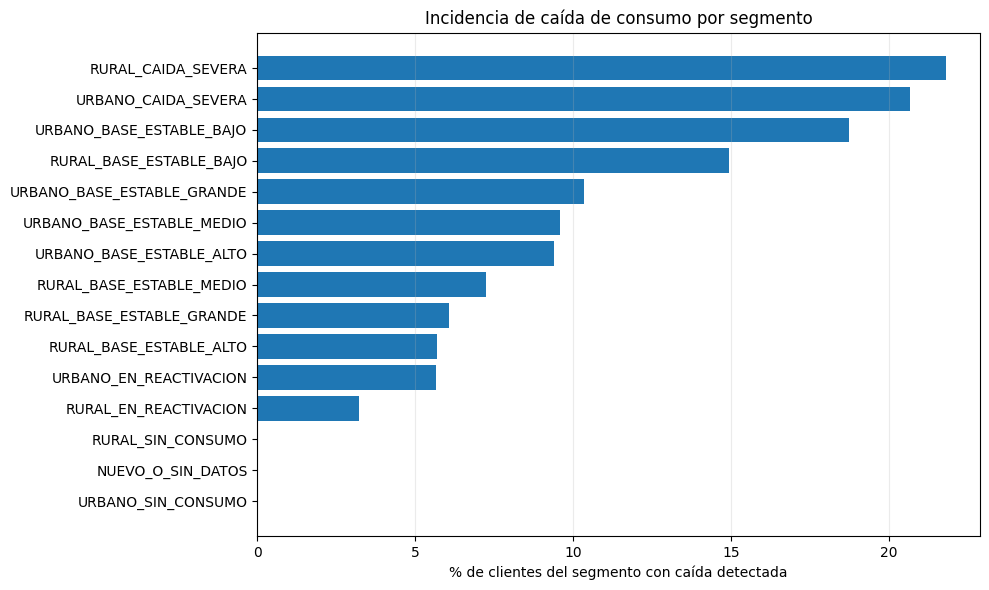

C:\Users\Home\AppData\Local\Temp\ipykernel_23900\1667906310.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_box, labels=segmentos_grandes, vert=True, showfliers=False)


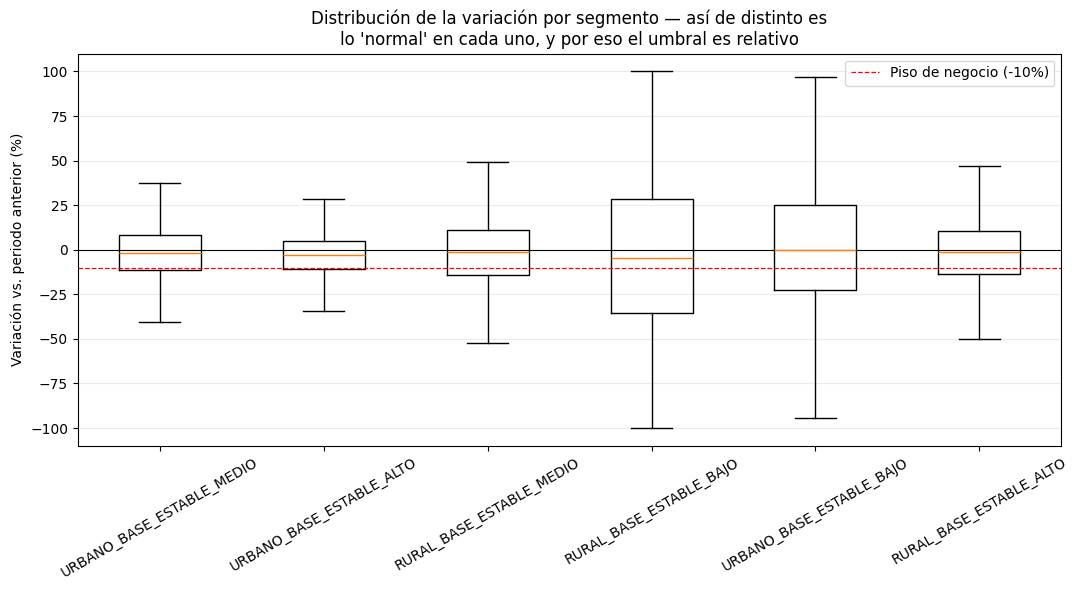

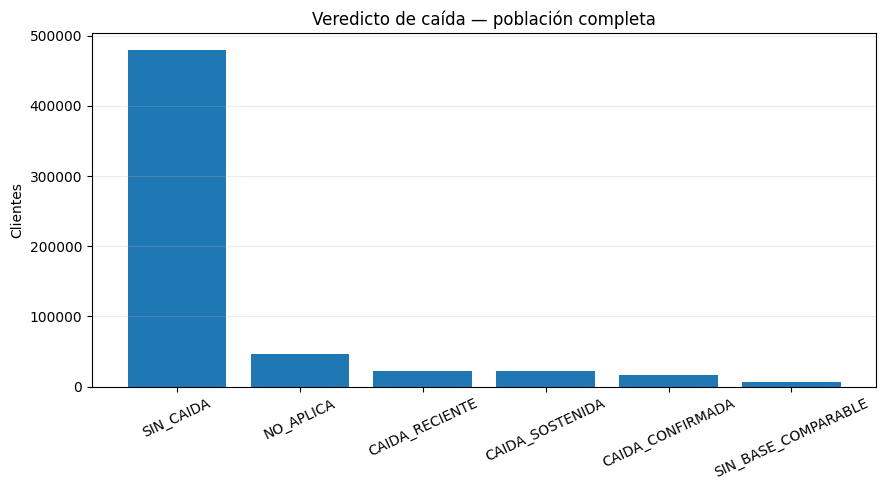

In [14]:
# ============================================================
# 13. GRÁFICAS
# ============================================================

# --- 1. % de clientes con caída por segmento ---
graf = resumen_segmento.sort_values("pct_con_caida", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(graf["cluster_id"], graf["pct_con_caida"])
ax.set_xlabel("% de clientes del segmento con caída detectada")
ax.set_title("Incidencia de caída de consumo por segmento")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

# --- 2. Distribución de la variación en los segmentos masivos ---
segmentos_grandes = (
    resumen_segmento.nlargest(6, "n_clientes")["cluster_id"].tolist()
)

fig, ax = plt.subplots(figsize=(11, 6))
datos_box = [
    caida.loc[
        (caida["cluster_id"] == s)
        & caida["variacion_vs_anterior_pct"].notna(),
        "variacion_vs_anterior_pct",
    ].clip(-100, 100)
    for s in segmentos_grandes
]
ax.boxplot(datos_box, labels=segmentos_grandes, vert=True, showfliers=False)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(UMBRAL_MINIMO_CAIDA_PCT, color="red", linestyle="--", linewidth=0.9,
           label=f"Piso de negocio ({UMBRAL_MINIMO_CAIDA_PCT:.0f}%)")
ax.set_ylabel("Variación vs. periodo anterior (%)")
ax.set_title("Distribución de la variación por segmento — así de distinto es\n"
             "lo 'normal' en cada uno, y por eso el umbral es relativo")
ax.tick_params(axis="x", rotation=30)
ax.legend()
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

# --- 3. Composición de veredictos ---
fig, ax = plt.subplots(figsize=(9, 5))
conteo = caida["veredicto"].value_counts()
ax.bar(conteo.index, conteo.values)
ax.set_ylabel("Clientes")
ax.set_title("Veredicto de caída — población completa")
ax.tick_params(axis="x", rotation=25)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# 14. CIERRE
# ============================================================

print("ESTUDIO DE CAÍDA DE CONSUMO — TERMINADO")
print("=" * 78)

print(f"\nPoblación evaluada : {len(caida):,} clientes")
print(f"Ventana mensual    : {MESES_VENTANA_MENSUAL} meses "
      f"({VENTANAS['MENSUAL']['reciente'][0]:%Y-%m} → "
      f"{VENTANAS['MENSUAL']['reciente'][-1]:%Y-%m})")
print(f"Ventana trimestral : {MESES_VENTANA_TRIMESTRAL} meses "
      f"({VENTANAS['TRIMESTRAL']['reciente'][0]:%Y-%m} → "
      f"{VENTANAS['TRIMESTRAL']['reciente'][-1]:%Y-%m})")

print("\nRESULTADO")
print("-" * 78)
for veredicto in ["CAIDA_CONFIRMADA", "CAIDA_SOSTENIDA", "CAIDA_RECIENTE"]:
    n = int((caida["veredicto"] == veredicto).sum())
    print(f"  {veredicto:<20}: {n:>7,} clientes")

print("\nSalidas:")
print(" •", RUTA_CAIDA, "(detalle por cliente)")
print(" •", RUTA_RESUMEN_SEGMENTO, "(tabla para negocio)")
print(" •", RUTA_PRIORITARIOS, "(lista accionable ordenada)")
print(" •", RUTA_DIAGNOSTICO_BORDE, "(diagnóstico del borde de la ventana)")
print(" •", RUTA_CRITERIOS, "(umbrales aplicados: para reaplicar el mismo criterio)")
print(" •", RUTA_CRITERIOS_CSV)


ESTUDIO DE CAÍDA DE CONSUMO — TERMINADO

Población evaluada : 592,159 clientes
Ventana mensual    : 3 meses (2025-10 → 2025-12)
Ventana trimestral : 6 meses (2025-07 → 2025-12)

RESULTADO
------------------------------------------------------------------------------
  CAIDA_CONFIRMADA    :  15,896 clientes
  CAIDA_SOSTENIDA     :  21,734 clientes
  CAIDA_RECIENTE      :  22,020 clientes

Salidas:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\estudio_caida_consumo.parquet (detalle por cliente)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\resumen_caida_por_segmento.csv (tabla para negocio)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\clientes_caida_prioritarios.csv (lista accionable ordenada)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\diagnostico_borde_ventana.csv (diagnóstico del borde de la ventana)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\cri